In [21]:
import pandas as pd
import seaborn as sns
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [22]:
sns.set_theme(style="whitegrid", font_scale=1.2)
sns.color_palette("husl")

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.7350228985632719, 0.5952719904750953, 0.1944419133847522),
 (0.3126890019504329, 0.6928754610296064, 0.1923704830330379),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.23299120924703914, 0.639586552066035, 0.9260706093977744),
 (0.9082572436765556, 0.40195790729656516, 0.9576909250290225)]

In [23]:
classes = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]

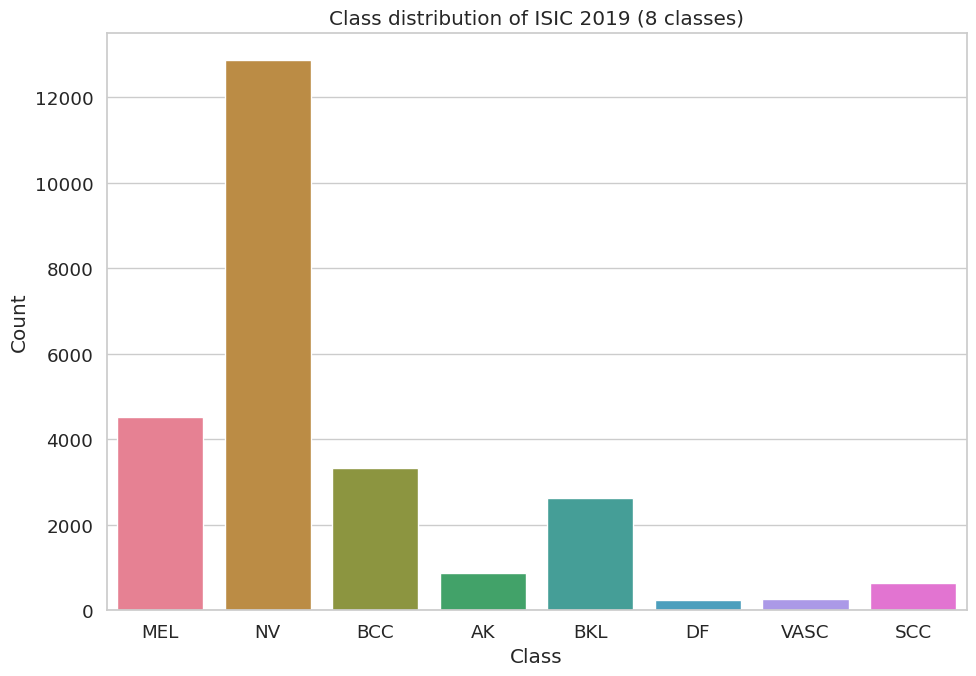

In [24]:
isic_img_labels = pd.read_csv("../../data/ISIC_2019_Training_GroundTruth.csv").drop(columns=["UNK"], errors="ignore")
isic_long = isic_img_labels.melt(id_vars=["image"], var_name="Class", value_name="value")
isic_long = isic_long[isic_long["value"] == 1.0]
isic_counts = isic_long["Class"].value_counts().reindex(classes, fill_value=0).rename_axis("Class").reset_index(name="Count")

plt.figure(figsize=(10, 7))
sns.barplot(data=isic_counts, x="Class", y="Count", hue="Class", palette='husl', legend=False)
plt.title("Class distribution of ISIC 2019 (8 classes)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

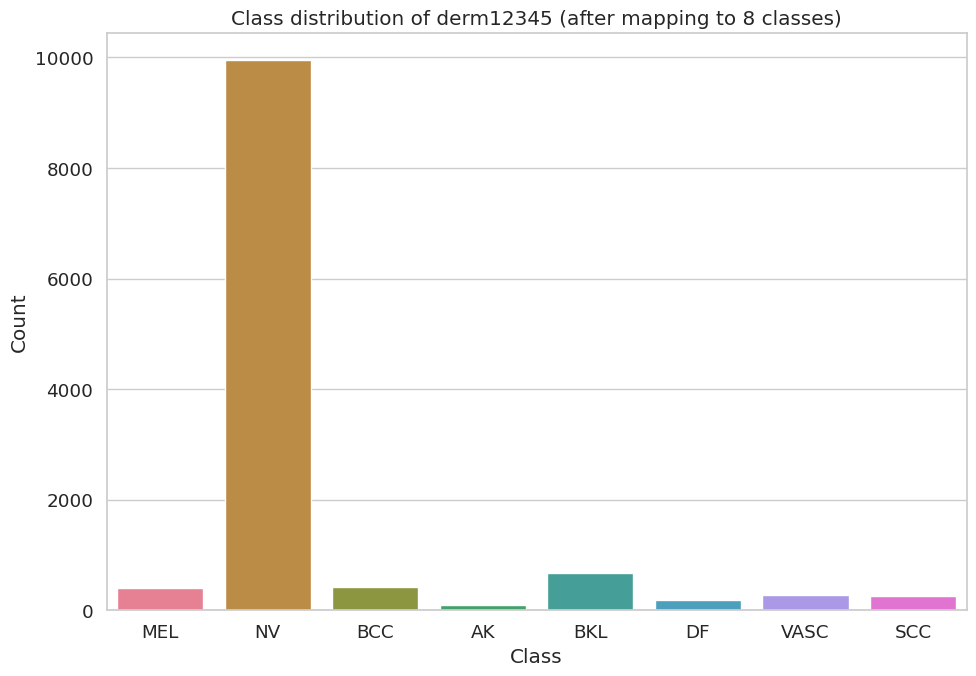

In [25]:
derm_isic_class_mapping_dict = {
    "MEL": ["anm", "alm", "lm", "lmm", "mel"],
    "NV": ["acb","ccb","mcb","cb","bdb","db","ajb","cjb","jb","acd","ccd","cd","ajd","srjd","jd","rd"],
    "BCC": ["bcc"],
    "AK": ["ak", "bd"],
    "BKL": ["sk", "sl", "lk"],
    "DF": ["df"],
    "VASC": ["angk","ha","la","pg","sa"],
    "SCC": ["scc"]
}
leaf_to_isic = {leaf: k for k, vs in derm_isic_class_mapping_dict.items() for leaf in vs}

derm_img_labels = pd.read_csv("../../data/derm12345/derm12345_supplemental.csv")
derm_img_labels["Class"] = derm_img_labels["label"].astype(str).str.strip().map(leaf_to_isic)
derm_counts = derm_img_labels.dropna(subset=["Class"])["Class"].value_counts().reindex(classes, fill_value=0).rename_axis("Class").reset_index(name="Count")

plt.figure(figsize=(10, 7))
sns.barplot(data=derm_counts, x="Class", y="Count", hue="Class", palette='husl', legend=False)
plt.title("Class distribution of derm12345 (after mapping to 8 classes)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

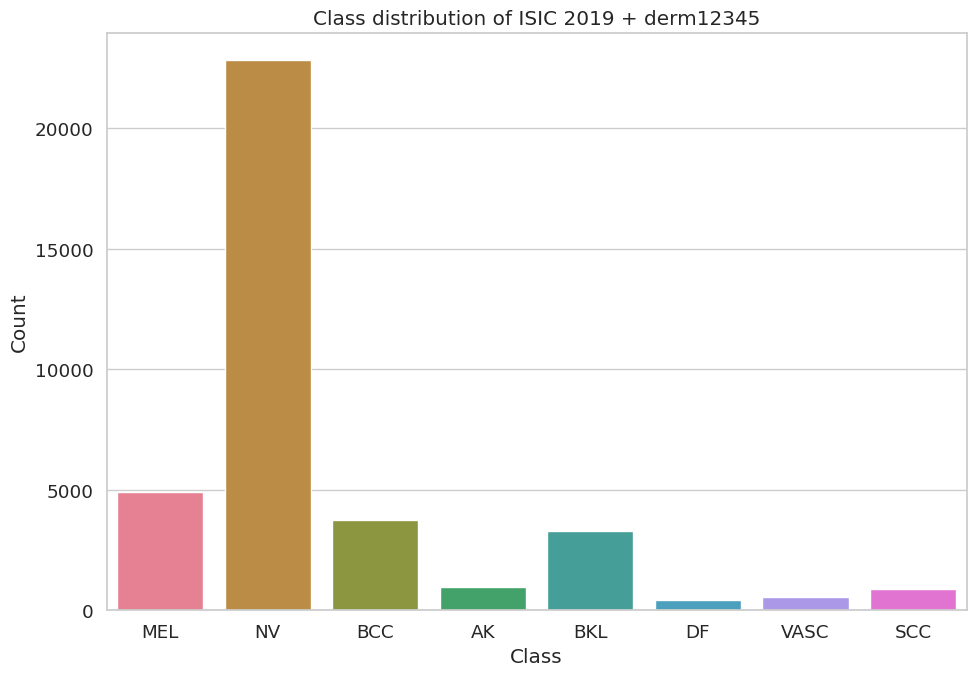

In [26]:
combined_counts = (
    isic_counts.set_index("Class")["Count"]
    .add(derm_counts.set_index("Class")["Count"], fill_value=0)
    .reindex(classes)
    .rename("Count")
    .reset_index()
)

plt.figure(figsize=(10, 7))
sns.barplot(data=combined_counts, x="Class", y="Count", hue="Class", palette='husl', legend=False)
plt.title("Class distribution of ISIC 2019 + derm12345")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()